In [14]:
import numpy as np
import time
from scipy.spatial import distance_matrix
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import scipy.stats as stats
import glob

## Genearte random classes
../gen_dataset.sh will generate 100 classes (25 sequences, with 2000 bits long) and save in the ../seqDatasets folder, then we can concatenate two random classes to for a bi-classification dataset;
- the parameters (number of classes, number of sequences, sequence length can be modified in ../gen_dataset.sh)
- more parameters could be changed (see manual of llk_baseChoice by using -h)
- that is where I have to use sleep(1).

## define the separation measurement. Return both the ratio and between-class distance.

In [36]:
def separation(D, labels):
    dim = len(D)
    A, B = 0, 0
    ca, cb = 0, 0
    for i in range(dim):
        for j in range(dim):
            k, l = labels[i], labels[j]
            if k == l:
                A += D[i][j]
                ca += 1
            else:
                B += D[i][j]
                cb += 1
    r = (A / ca) / (B / cb)
    return r, B # return both ratio (r) and between-class distance (B)

#------------------------------A test of validity--------------------------
# n1, n2 = 5, 5
# std1, std2 = .2, .2 # the smaller the stds the smaller the separation 
# labels = [0] * n1 + [1] * n2
# X1 = np.array([-1, -1]) + std1 * np.random.randn(n1, 2)
# X2 = np.array([1, 1]) + std2 * np.random.randn(n2, 2)
# X = np.vstack((X1, X2))
# D = distance_matrix(X, X)
# r, B = separation(D, labels)
# print('ratio = {}, between-class distance = {}'.format(r, B))

## Generate random base PFSA projectors
- user defined PFSA cfg files are saved to ../baseChoice_cfgfiles 

In [41]:
num_random_pfsa = 4
num_states_min, num_states_max = 2, 5
for i in range(num_random_pfsa):
    num_states = num_states_min + np.random.randint((num_states_max + 1 - num_states_min))
    ! ../genRandPFSA -a 2 -n {num_states} -p ../baseChoice_cfgfiles/PFSA_{i}.cfg
    time.sleep(1) # Node that I also have to use sleep here or otherwise we will have all the same PFSA

## Form bi-classification datasets and compare
- choose two classes randomly and concatenate the sequence files.
- run both the default lsmash and lsmash with user defined base PFSA
- save both ratio and between-class distance for plotting

In [42]:
labels = [0] * 25 + [1] * 25
num_runs = 200

r_lsmash, r_random = [], [] # the ratio (mean within-class distance) / (mean between-class distance)
B_lsmash, B_random = [], [] # the total between-class distance

for n in range(num_runs):
    i = np.random.randint(100) + 1
    j = np.random.randint(100) + 1

    ! cat ../seqDatasets/seq_{i}.dat ../seqDatasets/seq_{j}.dat > seq.dat
    
    # default four PFSA
    ! ../lsmash -f seq.dat -T symbolic -o lsmash.dst -S 0
    dist_lsmash = np.genfromtxt('lsmash.dst')
    r, B = separation(dist_lsmash, labels)
    r_lsmash.append(r)
    B_lsmash.append(B)
    
    # randomly generated base PFSA
    cmd = '../lsmash -f seq.dat -T symbolic -o random.dst -S 0 -F {}'.format(' '.join(glob.glob('../baseChoice_cfgfiles/*')))
    ! {cmd}
    dist_random = np.genfromtxt('random.dst')
    r, B = separation(dist_random, labels)
    r_random.append(r)
    B_random.append(B)

    print('round {}, ({}, {}), lsmash = {}, random={}'.format(n, i, j, r_lsmash[n], r_random[n]))

round 0, (66, 51), lsmash = 0.1770674489249076, random=0.09108546245466843
round 1, (98, 87), lsmash = 0.14041270401509498, random=0.10194323872053836
round 2, (46, 37), lsmash = 0.553989211399049, random=0.10421342975275977
round 3, (36, 89), lsmash = 0.08152244136030319, random=0.06037553128918935
round 4, (46, 72), lsmash = 0.1486849488758885, random=0.10128270882435854
round 5, (93, 47), lsmash = 0.4352815961606746, random=0.1180110074047443
round 6, (92, 20), lsmash = 0.15831545632582916, random=0.18686730030862933
round 7, (61, 13), lsmash = 0.15532737004778266, random=0.4114610645608307
round 8, (93, 43), lsmash = 0.6895971779096266, random=0.1372205090989749
round 9, (66, 20), lsmash = 0.5724316554431557, random=0.47637126327039214
round 10, (7, 85), lsmash = 0.11541225057759279, random=0.07363152953895254
round 11, (48, 100), lsmash = 0.15724216446467637, random=0.48661184353497655
round 12, (25, 11), lsmash = 0.1558470004846255, random=0.1703588502402548
round 13, (68, 16), l

## Histograms

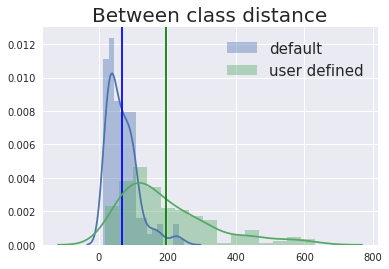

In [39]:
plt.figure()
ax = sns.distplot(B_lsmash, bins=15, label='default')
ax.axvline(np.mean(B_lsmash), color='blue')
sns.distplot(B_random, bins=15, label='user defined')
ax.axvline(np.mean(B_random), color='green')
plt.legend(fontsize=15)
plt.title('Between class distance', fontsize=20)
plt.show()

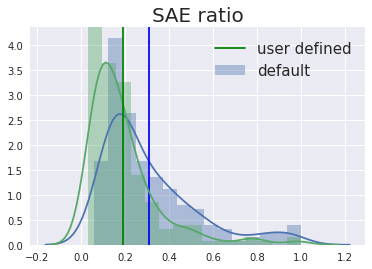

In [40]:
plt.figure()
ax = sns.distplot(r_lsmash, bins=15, label='default')
ax.axvline(np.mean(r_lsmash), color='blue')
sns.distplot(r_random, bins=15)
ax.axvline(np.mean(r_random), color='green', label='user defined')
plt.legend(fontsize=15)
plt.title('SAE ratio', fontsize=20)
plt.show()